# F1 Podium Prediction Companion — Section 2: Data-Engineering Questions

This notebook answers the three data-engineering questions of Milestone 1. Each answer uses **multi-hop joins** across the Ergast tables, is backed by a **plot + statistic**, and states the **grain**, the **missingness** handling and (where relevant) the **pre-race cutoff**.

| # | Question | Tables joined |
|---|---|---|
| Q1 | Which circuits convert a front-row start into a podium most often, and does the ranking change after 2014? Qualifying position vs. grid. | `results` → `races` → `circuits`, + `qualifying` |
| Q2 | Do drivers podium more often at home, after controlling for starting position? | `results` → `races` → `circuits`, + `drivers` |
| Q3 | Which constructors have the highest mechanical-retirement rate in 2014–2021 vs. 2022–2024? | `results` → `status`, + `races`, `constructors` |

**Structure**
0. Setup & data loading
1. Shared preparation (sentinels, typing, key checks, one row per driver–race)
2. Q1 — Front-row → podium conversion by circuit
3. Q2 — Home-country advantage, controlled for grid
4. Q3 — Mechanical-retirement rate by constructor
5. Summary of answers

> The shared preparation in Section 1 is deliberately small and self-contained so this section runs on its own. If the team's main cleaning pipeline already produces a cleaned `results` table, it can be dropped in place of `res` in Section 1.4.

## 0. Setup & data loading

In [20]:
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

HYBRID_START = 2014          # first season of the V6 turbo-hybrid era
LAST_SEASON = 2024          # the brief covers 1950–2024; newer dataset versions are cut here
FIG_DIR = "figures_data_engineering"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    # Save every figure so it can be reused in the PDF report.
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")

def wilson(successes, n, alpha=0.05):
    # Wilson score interval: well-behaved for small n and rates near 0 or 1.
    lo, hi = proportion_confint(successes, n, alpha=alpha, method="wilson")
    return lo, hi

In [21]:
def find_data_dir():
    # Works on Kaggle (dataset attached as input) and locally (CSVs in ./data or next to the notebook).
    candidates = [
        os.environ.get("F1_DATA_DIR", ""),
        "/kaggle/input/formula-1-world-championship-1950-2024",
        "./data", ".", "..",
    ]
    for c in candidates:
        if c and os.path.exists(os.path.join(c, "results.csv")):
            return c
    hits = glob.glob("/kaggle/input/**/results.csv", recursive=True)
    if hits:
        return os.path.dirname(hits[0])
    raise FileNotFoundError("Could not find the Ergast CSVs. Set F1_DATA_DIR to the folder containing results.csv.")

DATA_DIR = find_data_dir()
# print("Reading CSVs from:", DATA_DIR)

TABLES = ["circuits", "constructors", "drivers", "races", "results", "qualifying", "status"]

# Raw tables stay immutable: they are read once and never modified.
# '\N' is the Ergast "missing" sentinel. keep_default_na=False stops pandas from
# silently turning legitimate strings such as "NA" into NaN.
raw = {t: pd.read_csv(os.path.join(DATA_DIR, f"{t}.csv"),
                      na_values=["\\N", ""], keep_default_na=False)
       for t in TABLES}
tbl = {t: df.copy() for t, df in raw.items()}   # working copies

pd.DataFrame({t: {"rows": len(df), "cols": df.shape[1]} for t, df in raw.items()}).T

,rows,cols
circuits,77,9
constructors,212,5
drivers,861,9
races,1125,18
results,26759,18
qualifying,10494,9
status,139,2


## 1. Shared preparation

### 1.1 Sentinels and semantic typing
We count how many `\N` sentinels each column used (they are now `NaN`), then cast columns to their semantic types: dates to `datetime`, positions/grid/ids to numeric.

In [22]:
# How many '\N' sentinels per column? (count from the raw text so the number is exact)
sentinel_rows = []
for t in TABLES:
    txt = pd.read_csv(os.path.join(DATA_DIR, f"{t}.csv"), dtype=str, keep_default_na=False)
    for c in txt.columns:
        n = (txt[c] == "\\N").sum()
        if n:
            sentinel_rows.append({"table": t, "column": c, "n_sentinel": n, "share": n / len(txt)})
sentinels = pd.DataFrame(sentinel_rows).sort_values("share", ascending=False)
sentinels.head(25)

,table,column,n_sentinel,share
12,races,sprint_time,1110,0.986667
11,races,sprint_date,1107,0.984000
8,races,fp3_time,1072,0.952889
6,races,fp2_time,1057,0.939556
10,races,quali_time,1057,0.939556
4,races,fp1_time,1057,0.939556
7,races,fp3_date,1053,0.936000
0,drivers,number,802,0.931475
9,races,quali_date,1035,0.920000
3,races,fp1_date,1035,0.920000


In [23]:
# Columns used in this section
tbl["races"]["date"] = pd.to_datetime(tbl["races"]["date"], errors="coerce")
tbl["drivers"]["dob"] = pd.to_datetime(tbl["drivers"]["dob"], errors="coerce")

num_cols = {
    "results": ["resultId", "raceId", "driverId", "constructorId", "grid", "position", "positionOrder", "points", "laps", "statusId"],
    "qualifying": ["qualifyId", "raceId", "driverId", "constructorId", "position"],
    "races": ["raceId", "year", "round", "circuitId"],
}
for t, cols in num_cols.items():
    for c in cols:
        tbl[t][c] = pd.to_numeric(tbl[t][c], errors="coerce")

# Normalise circuit country spellings so a country is one label
COUNTRY_NORMALISE = {"United States": "USA", "United Kingdom": "UK", "South Korea": "Korea",
                     "United Arab Emirates": "UAE"}
tbl["circuits"]["country"] = tbl["circuits"]["country"].str.strip().replace(COUNTRY_NORMALISE)
tbl["drivers"]["nationality"] = tbl["drivers"]["nationality"].str.strip()
tbl["status"]["status"] = tbl["status"]["status"].str.strip()

tbl["results"][num_cols["results"]].dtypes.to_frame("dtype").T

,resultId,raceId,driverId,constructorId,grid,position,positionOrder,points,laps,statusId
dtype,int64,int64,int64,int64,int64,float64,int64,float64,int64,int64


### 1.2 Primary- and foreign-key checks
Every join below relies on these keys. A primary key must be unique and non-null; every foreign key must exist in the table it points to (no orphans). We use `validate="m:1"` in every merge as an extra guard.

In [24]:
def pk_check(df, cols, name):
    return {"table": name, "key": "+".join(cols), "rows": len(df),
            "duplicate_keys": int(df.duplicated(cols).sum()),
            "null_keys": int(df[cols].isna().any(axis=1).sum())}

def fk_check(child, ccol, parent, pcol, name):
    vals = child[ccol].dropna()
    return {"foreign_key": name, "values": len(vals),
            "orphans": int((~vals.isin(parent[pcol])).sum())}

pk = pd.DataFrame([
    pk_check(tbl["circuits"], ["circuitId"], "circuits"),
    pk_check(tbl["constructors"], ["constructorId"], "constructors"),
    pk_check(tbl["drivers"], ["driverId"], "drivers"),
    pk_check(tbl["races"], ["raceId"], "races"),
    pk_check(tbl["results"], ["resultId"], "results"),
    pk_check(tbl["qualifying"], ["qualifyId"], "qualifying"),
    pk_check(tbl["status"], ["statusId"], "status"),
])
fk = pd.DataFrame([
    fk_check(tbl["results"], "raceId", tbl["races"], "raceId", "results.raceId → races"),
    fk_check(tbl["results"], "driverId", tbl["drivers"], "driverId", "results.driverId → drivers"),
    fk_check(tbl["results"], "constructorId", tbl["constructors"], "constructorId", "results.constructorId → constructors"),
    fk_check(tbl["results"], "statusId", tbl["status"], "statusId", "results.statusId → status"),
    fk_check(tbl["qualifying"], "raceId", tbl["races"], "raceId", "qualifying.raceId → races"),
    fk_check(tbl["qualifying"], "driverId", tbl["drivers"], "driverId", "qualifying.driverId → drivers"),
    fk_check(tbl["races"], "circuitId", tbl["circuits"], "circuitId", "races.circuitId → circuits"),
])
display(pk); display(fk)
print("Primary keys OK" if pk[["duplicate_keys", "null_keys"]].sum().sum() == 0 else "WARNING: primary-key problem above")
print("Foreign keys OK" if fk["orphans"].sum() == 0 else "WARNING: orphan foreign keys above (rows are kept out by the inner logic of each join)")

,table,key,rows,duplicate_keys,null_keys
0,circuits,circuitId,77,0,0
1,constructors,constructorId,212,0,0
2,drivers,driverId,861,0,0
3,races,raceId,1125,0,0
4,results,resultId,26759,0,0
5,qualifying,qualifyId,10494,0,0
6,status,statusId,139,0,0


,foreign_key,values,orphans
0,results.raceId → races,26759,0
1,results.driverId → drivers,26759,0
2,results.constructorId → constructors,26759,0
3,results.statusId → status,26759,0
4,qualifying.raceId → races,10494,0
5,qualifying.driverId → drivers,10494,0
6,races.circuitId → circuits,1125,0


Primary keys OK
Foreign keys OK


### 1.3 One row per (raceId, driverId)
Shared drives (mostly 1950s) give some drivers two rows in the same race.

**Rule:** keep the driver's **best-classified row** (lowest `positionOrder`), because that is the result officially credited to the driver, which is what "did this driver podium?" asks. The **starting grid** is taken separately as the driver's best positive grid slot across his rows, because that is the car he actually started in (the relieved/second car often carries `grid = 0`).

Rows involved in duplicate (raceId, driverId) pairs: 176 (85 driver-race pairs)


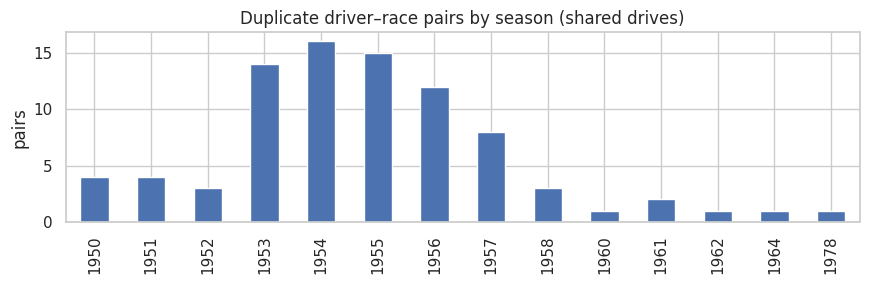

Rows after de-duplication: 26668


In [25]:
res = tbl["results"].copy()
dup_mask = res.duplicated(["raceId", "driverId"], keep=False)
dups = res[dup_mask].merge(tbl["races"][["raceId", "year"]], on="raceId")
print(f"Rows involved in duplicate (raceId, driverId) pairs: {dup_mask.sum()} "
      f"({dups[['raceId','driverId']].drop_duplicates().shape[0]} driver-race pairs)")

fig, ax = plt.subplots(figsize=(9, 3))
(dups.drop_duplicates(["raceId", "driverId"]).groupby("year").size()
     .plot(kind="bar", ax=ax, color="#4C72B0"))
ax.set(title="Duplicate driver–race pairs by season (shared drives)", xlabel="", ylabel="pairs")
plt.tight_layout(); savefig("00_duplicate_pairs"); plt.show()

start_grid = (res.assign(g=res["grid"].where(res["grid"] > 0))
                 .groupby(["raceId", "driverId"])["g"].min().rename("start_grid"))
res = (res.sort_values(["raceId", "driverId", "positionOrder"])
          .drop_duplicates(["raceId", "driverId"], keep="first")
          .merge(start_grid, on=["raceId", "driverId"], how="left"))
res["grid"] = res["start_grid"].fillna(0).astype(int)   # 0 = pit-lane start / unknown
res = res.drop(columns="start_grid")
assert not res.duplicated(["raceId", "driverId"]).any()
print("Rows after de-duplication:", len(res))

### 1.4 Base analytical table (grain: one driver entering one race)
`results → races → circuits`, `→ drivers`, `→ constructors`, `→ status`.
`podium = positionOrder ≤ 3` (outcome, never used as a feature). `grid` and qualifying position are known **before** the race and are the only pre-race inputs used in Q1–Q2.

In [26]:
races = tbl["races"][["raceId", "year", "round", "circuitId", "name", "date"]].rename(columns={"name": "race_name"})
circuits = tbl["circuits"][["circuitId", "circuitRef", "name", "country"]].rename(
    columns={"name": "circuit_name", "country": "circuit_country"})
drivers = tbl["drivers"][["driverId", "driverRef", "forename", "surname", "nationality"]].rename(
    columns={"nationality": "driver_nationality"})
constructors = tbl["constructors"][["constructorId", "constructorRef", "name"]].rename(columns={"name": "constructor"})

base = (res[["raceId", "driverId", "constructorId", "grid", "positionOrder", "laps", "statusId"]]
        .merge(races, on="raceId", how="left", validate="m:1")
        .merge(circuits, on="circuitId", how="left", validate="m:1")
        .merge(drivers, on="driverId", how="left", validate="m:1")
        .merge(constructors, on="constructorId", how="left", validate="m:1")
        .merge(tbl["status"], on="statusId", how="left", validate="m:1"))
base["podium"] = (base["positionOrder"] <= 3).astype(int)
base = base[base["year"] <= LAST_SEASON].copy()
base["era"] = np.where(base["year"] >= HYBRID_START, f"{HYBRID_START}+ (hybrid)", f"pre-{HYBRID_START}")

print(base.shape)
base.isna().sum().loc[lambda s: s > 0]

(26668, 24)


Series([], dtype: int64)

## 2. Q1 — Which circuits convert a front-row start into a podium most often? Does it change after 2014?

**Definitions**
- *Front row by qualifying*: `qualifying.position ∈ {1, 2}`.
- *Front row by grid*: `results.grid ∈ {1, 2}` — the slot the car **actually** started from, after penalties, pit-lane starts, and (2021–22) sprint results.
- *Conversion* = share of front-row starters who finished on the podium.

**Grain:** one front-row starter in one race (≈ 2 rows per race). **Pre-race cutoff:** both qualifying position and grid are fixed before lights-out; the podium is the outcome only.

**Missingness:** `qualifying` does not cover early decades. We measure coverage per season and only use seasons where it is complete, so the qualifying and grid definitions are compared on the *same races*. In the Ergast data this means **2003–2024**, so in Q1 "pre-2014" means **2003–2013**.

Qualifying coverage is ≥90% in every season from 2003 onward → Q1 uses 2003–2024.


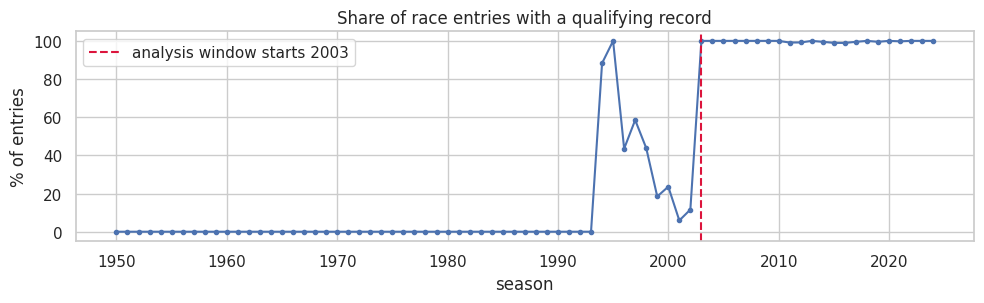

In [27]:
quali = (tbl["qualifying"][["raceId", "driverId", "position"]]
         .rename(columns={"position": "quali_pos"})
         .groupby(["raceId", "driverId"], as_index=False)["quali_pos"].min())

q1 = base.merge(quali, on=["raceId", "driverId"], how="left", validate="1:1")
coverage = q1.groupby("year")["quali_pos"].apply(lambda s: s.notna().mean())

bad_years = coverage.index[coverage < 0.90]
QUALI_START = int(bad_years.max() + 1) if len(bad_years) else int(coverage.index.min())
print(f"Qualifying coverage is ≥90% in every season from {QUALI_START} onward → Q1 uses {QUALI_START}–{int(q1.year.max())}.")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(coverage.index, coverage.values * 100, marker=".", color="#4C72B0")
ax.axvline(QUALI_START, color="crimson", ls="--", label=f"analysis window starts {QUALI_START}")
ax.set(title="Share of race entries with a qualifying record", ylabel="% of entries", xlabel="season")
ax.legend(); plt.tight_layout(); savefig("q1_qualifying_coverage"); plt.show()

### 2.1 Qualifying position ≠ grid: how often, and does it matter?

,n,podiums,podium_rate,ci_lo,ci_hi
fr_case,,,,,
Promoted to front row (did not qualify there),36,23,0.638889,0.475751,0.775244
Qualified & started on front row,818,594,0.726161,0.694599,0.755610
"Qualified front row, started further back",38,11,0.289474,0.170033,0.447571


,definition,n,podiums,rate
0,qualifying P1–P2,856,605,0.706776
1,grid P1–P2,854,617,0.722482


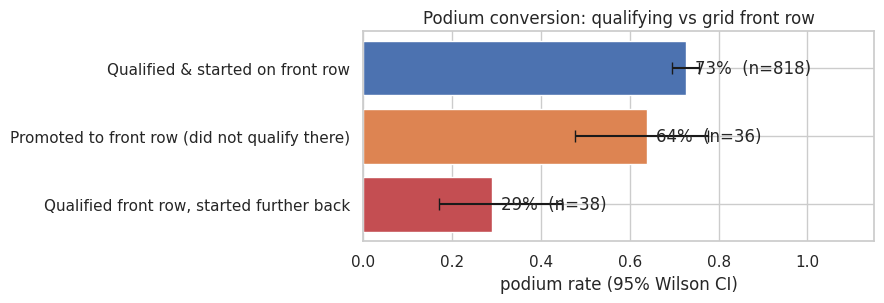

In [28]:
q1 = q1[q1["year"] >= QUALI_START].copy()
q1["fr_quali"] = q1["quali_pos"].isin([1, 2])
q1["fr_grid"] = q1["grid"].isin([1, 2])

def label(row):
    if row.fr_quali and row.fr_grid: return "Qualified & started on front row"
    if row.fr_quali: return "Qualified front row, started further back"
    if row.fr_grid: return "Promoted to front row (did not qualify there)"
    return None
q1["fr_case"] = q1.apply(label, axis=1)

cases = (q1.dropna(subset=["fr_case"]).groupby("fr_case")
           .agg(n=("podium", "size"), podiums=("podium", "sum")))
cases["podium_rate"] = cases.podiums / cases.n
cases["ci_lo"], cases["ci_hi"] = wilson(cases.podiums, cases.n)
display(cases)

overall = pd.DataFrame({
    "definition": ["qualifying P1–P2", "grid P1–P2"],
    "n": [q1.fr_quali.sum(), q1.fr_grid.sum()],
    "podiums": [q1.loc[q1.fr_quali, "podium"].sum(), q1.loc[q1.fr_grid, "podium"].sum()],
})
overall["rate"] = overall.podiums / overall.n
display(overall)

fig, ax = plt.subplots(figsize=(9, 3.2))
c = cases.sort_values("podium_rate")
ax.barh(c.index, c.podium_rate, xerr=[c.podium_rate - c.ci_lo, c.ci_hi - c.podium_rate],
        color=["#C44E52", "#DD8452", "#4C72B0"][:len(c)], capsize=4)
for i, (r, n) in enumerate(zip(c.podium_rate, c.n)):
    ax.text(r + 0.02, i, f"{r:.0%}  (n={n})", va="center")
ax.set(xlim=(0, 1.15), xlabel="podium rate (95% Wilson CI)", title="Podium conversion: qualifying vs grid front row")
plt.tight_layout(); savefig("q1_quali_vs_grid"); plt.show()

### 2.2 Conversion rate per circuit and era
Circuits with very few front-row starts give noisy rates (2/2 = 100%). We therefore require **at least `MIN_N` front-row starts per era** and **rank by the lower bound of the 95% Wilson interval**, which favours circuits that convert often *and* have enough evidence. The raw rate is still shown.

In [29]:
MIN_N = 10   # front-row starts per circuit per era (≈ 5 races)

def conversion_table(df, flag):
    g = (df[df[flag]].groupby(["era", "circuit_name"])
           .agg(n=("podium", "size"), podiums=("podium", "sum"), races=("raceId", "nunique"))
           .reset_index())
    g["rate"] = g.podiums / g.n
    g["ci_lo"], g["ci_hi"] = wilson(g.podiums, g.n)
    g = g[g.n >= MIN_N].copy()
    g["rank"] = g.groupby("era")["ci_lo"].rank(ascending=False, method="min").astype(int)
    return g.sort_values(["era", "rank"])

conv = {"grid": conversion_table(q1, "fr_grid"), "qualifying": conversion_table(q1, "fr_quali")}
ERAS = [f"pre-{HYBRID_START}", f"{HYBRID_START}+ (hybrid)"]
for d, t in conv.items():
    print(f"\nTop 10 by {d} front row")
    for e in ERAS:
        display(t[t.era == e].head(10)[["era", "rank", "circuit_name", "races", "n", "podiums", "rate", "ci_lo", "ci_hi"]]
                .style.format({"rate": "{:.0%}", "ci_lo": "{:.0%}", "ci_hi": "{:.0%}"}).hide(axis="index"))


Top 10 by grid front row


era,rank,circuit_name,races,n,podiums,rate,ci_lo,ci_hi
pre-2014,1,Circuit de Nevers Magny-Cours,6,12,11,92%,65%,99%
pre-2014,2,Autodromo Nazionale di Monza,11,22,17,77%,57%,90%
pre-2014,2,Circuit de Monaco,11,22,17,77%,57%,90%
pre-2014,4,Istanbul Park,7,14,11,79%,52%,92%
pre-2014,5,Silverstone Circuit,11,22,16,73%,52%,87%
pre-2014,6,Circuit de Spa-Francorchamps,9,18,13,72%,49%,88%
pre-2014,6,Suzuka Circuit,9,18,13,72%,49%,88%
pre-2014,8,Circuit de Barcelona-Catalunya,11,22,15,68%,47%,84%
pre-2014,9,Hockenheimring,7,14,10,71%,45%,88%
pre-2014,10,Bahrain International Circuit,9,18,12,67%,44%,84%


era,rank,circuit_name,races,n,podiums,rate,ci_lo,ci_hi
2014+ (hybrid),1,Suzuka Circuit,9,18,16,89%,67%,97%
2014+ (hybrid),2,Yas Marina Circuit,11,22,19,86%,67%,95%
2014+ (hybrid),3,Circuit de Monaco,10,20,17,85%,64%,95%
2014+ (hybrid),4,Circuit de Barcelona-Catalunya,11,22,18,82%,61%,93%
2014+ (hybrid),4,Circuit de Spa-Francorchamps,11,22,18,82%,61%,93%
2014+ (hybrid),6,Circuit of the Americas,10,20,16,80%,58%,92%
2014+ (hybrid),7,Sochi Autodrom,8,16,13,81%,57%,93%
2014+ (hybrid),8,Autódromo José Carlos Pace,10,19,15,79%,57%,91%
2014+ (hybrid),9,Silverstone Circuit,12,24,18,75%,55%,88%
2014+ (hybrid),10,Circuit Gilles Villeneuve,9,18,14,78%,55%,91%



Top 10 by qualifying front row


era,rank,circuit_name,races,n,podiums,rate,ci_lo,ci_hi
pre-2014,1,Circuit de Nevers Magny-Cours,6,12,11,92%,65%,99%
pre-2014,2,Silverstone Circuit,11,22,17,77%,57%,90%
pre-2014,3,Istanbul Park,7,14,11,79%,52%,92%
pre-2014,4,Autodromo Nazionale di Monza,11,22,16,73%,52%,87%
pre-2014,5,Circuit de Spa-Francorchamps,9,18,13,72%,49%,88%
pre-2014,5,Suzuka Circuit,9,18,13,72%,49%,88%
pre-2014,7,Shanghai International Circuit,10,20,14,70%,48%,85%
pre-2014,8,Circuit de Monaco,11,22,15,68%,47%,84%
pre-2014,9,Hockenheimring,7,14,10,71%,45%,88%
pre-2014,10,Bahrain International Circuit,9,18,12,67%,44%,84%


era,rank,circuit_name,races,n,podiums,rate,ci_lo,ci_hi
2014+ (hybrid),1,Suzuka Circuit,9,18,16,89%,67%,97%
2014+ (hybrid),2,Circuit de Monaco,10,20,17,85%,64%,95%
2014+ (hybrid),3,Circuit de Barcelona-Catalunya,11,22,18,82%,61%,93%
2014+ (hybrid),3,Circuit de Spa-Francorchamps,11,22,18,82%,61%,93%
2014+ (hybrid),3,Yas Marina Circuit,11,22,18,82%,61%,93%
2014+ (hybrid),6,Sochi Autodrom,8,16,13,81%,57%,93%
2014+ (hybrid),7,Silverstone Circuit,12,24,18,75%,55%,88%
2014+ (hybrid),8,Circuit of the Americas,10,20,15,75%,53%,89%
2014+ (hybrid),9,Shanghai International Circuit,7,14,11,79%,52%,92%
2014+ (hybrid),10,Autodromo Nazionale di Monza,11,22,16,73%,52%,87%


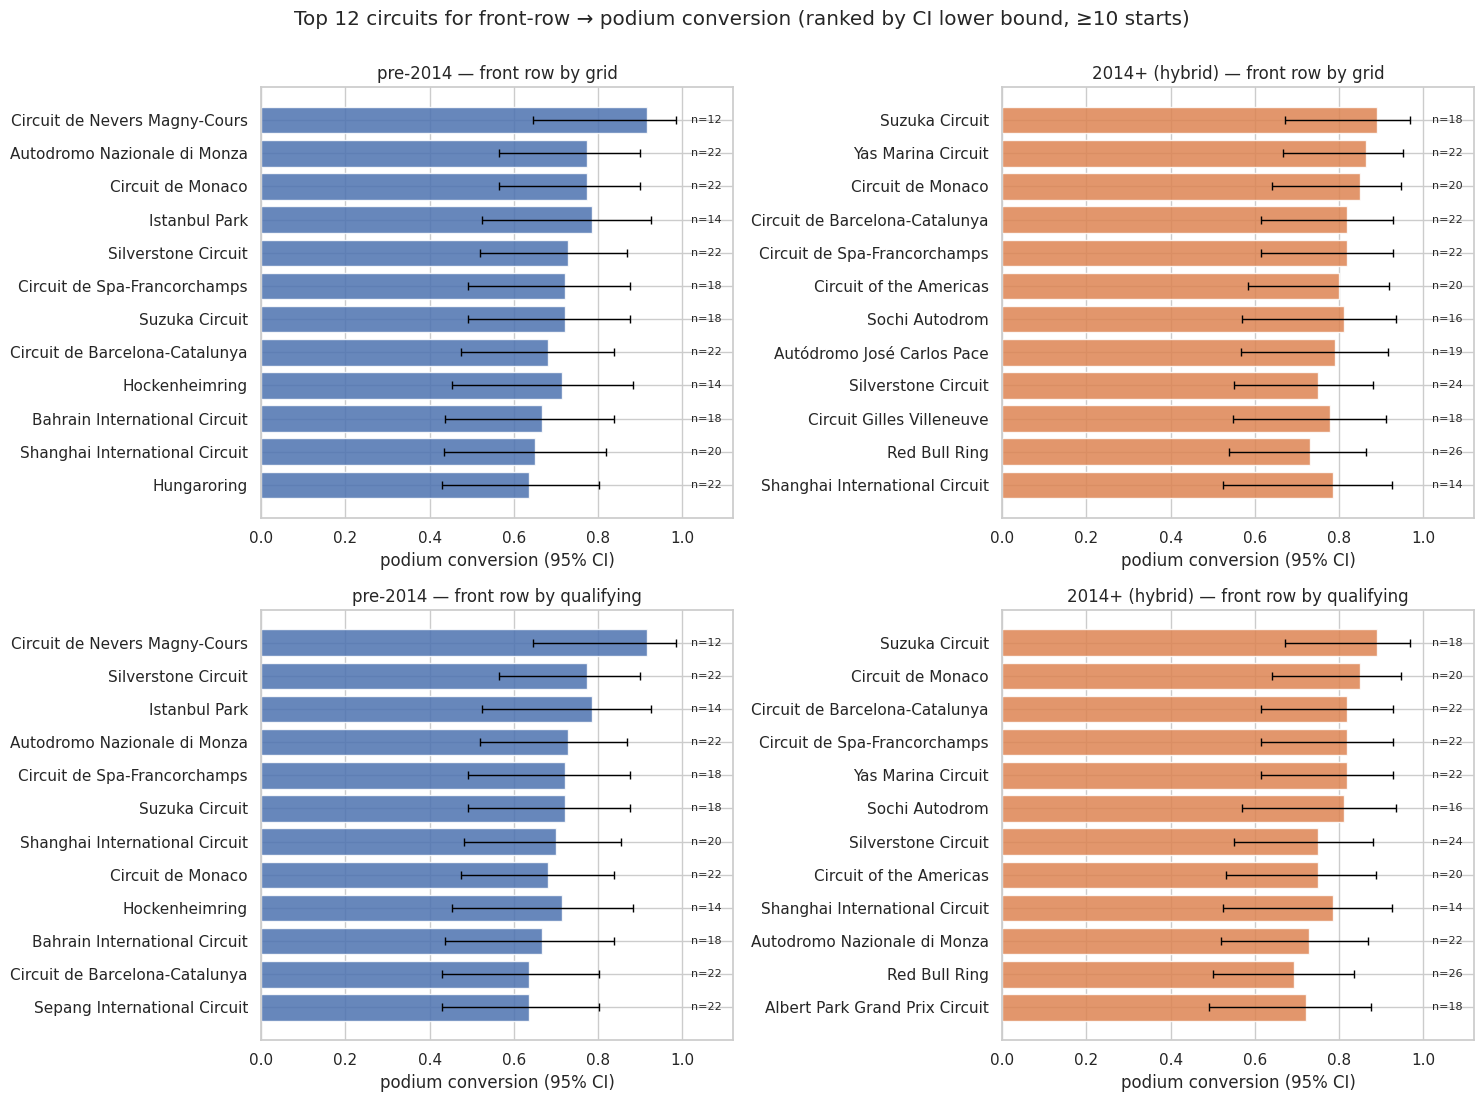

In [30]:
TOP = 12
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for i, d in enumerate(["grid", "qualifying"]):
    for j, e in enumerate(ERAS):
        ax = axes[i, j]
        t = conv[d][conv[d].era == e].head(TOP).iloc[::-1]
        ax.barh(t.circuit_name, t.rate, color="#4C72B0" if j == 0 else "#DD8452", alpha=.85)
        ax.errorbar(t.rate, t.circuit_name, xerr=[t.rate - t.ci_lo, t.ci_hi - t.rate],
                    fmt="none", ecolor="black", capsize=3, lw=1)
        for y, (r, n) in enumerate(zip(t.rate, t.n)):
            ax.text(1.02, y, f"n={n}", va="center", fontsize=8)
        ax.set(xlim=(0, 1.12), title=f"{e} — front row by {d}", xlabel="podium conversion (95% CI)")
fig.suptitle(f"Top {TOP} circuits for front-row → podium conversion (ranked by CI lower bound, ≥{MIN_N} starts)", y=1.0)
plt.tight_layout(); savefig("q1_top_circuits"); plt.show()

### 2.3 Does the ranking change after 2014?
For circuits with enough data in **both** eras we compare their ranks (Spearman ρ) and show the movers. We also check how much the ranking depends on the definition (qualifying vs grid) within each era.

In [31]:
def era_comparison(t):
    w = t.pivot(index="circuit_name", columns="era", values=["rate", "n"]).dropna()
    w.columns = [f"{a}_{b}" for a, b in w.columns]
    pre, post = ERAS
    w["rank_pre"] = w[f"rate_{pre}"].rank(ascending=False, method="first")
    w["rank_post"] = w[f"rate_{post}"].rank(ascending=False, method="first")
    w["rank_change"] = w["rank_pre"] - w["rank_post"]   # positive = climbed after 2014
    return w

cmp_grid = era_comparison(conv["grid"])
rho, p = stats.spearmanr(cmp_grid["rank_pre"], cmp_grid["rank_post"])
print(f"Circuits with ≥{MIN_N} grid front-row starts in both eras: {len(cmp_grid)}")
print(f"Spearman rank correlation pre-2014 vs 2014+: ρ = {rho:.2f} (p = {p:.3f})")
display(cmp_grid.sort_values("rank_change")[[f"rate_{ERAS[0]}", f"rate_{ERAS[1]}", "rank_pre", "rank_post", "rank_change"]]
        .style.format({f"rate_{ERAS[0]}": "{:.0%}", f"rate_{ERAS[1]}": "{:.0%}", "rank_pre": "{:.0f}",
                       "rank_post": "{:.0f}", "rank_change": "{:+.0f}"}))

# within-era agreement of the two definitions
for e in ERAS:
    a = conv["grid"].query("era == @e").set_index("circuit_name")["rate"]
    b = conv["qualifying"].query("era == @e").set_index("circuit_name")["rate"]
    j = pd.concat([a, b], axis=1, keys=["grid", "quali"]).dropna()
    r, pv = stats.spearmanr(j.grid, j.quali)
    print(f"{e}: grid-vs-qualifying ranking agreement ρ = {r:.2f} over {len(j)} circuits; "
          f"mean |rate difference| = {(j.grid - j.quali).abs().mean():.1%}")

Circuits with ≥10 grid front-row starts in both eras: 14
Spearman rank correlation pre-2014 vs 2014+: ρ = 0.25 (p = 0.383)


,rate_pre-2014,rate_2014+ (hybrid),rank_pre,rank_post,rank_change
circuit_name,,,,,
Autodromo Nazionale di Monza,77%,73%,1,10,-9
Bahrain International Circuit,67%,67%,7,13,-6
Silverstone Circuit,73%,75%,3,9,-6
Hungaroring,64%,59%,9,14,-5
Circuit de Monaco,77%,85%,2,3,-1
Circuit de Spa-Francorchamps,72%,82%,4,5,-1
Albert Park Grand Prix Circuit,59%,72%,12,11,+1
Shanghai International Circuit,65%,79%,8,7,+1
Circuit de Barcelona-Catalunya,68%,82%,6,4,+2


pre-2014: grid-vs-qualifying ranking agreement ρ = 0.94 over 21 circuits; mean |rate difference| = 1.5%
2014+ (hybrid): grid-vs-qualifying ranking agreement ρ = 0.88 over 19 circuits; mean |rate difference| = 2.4%


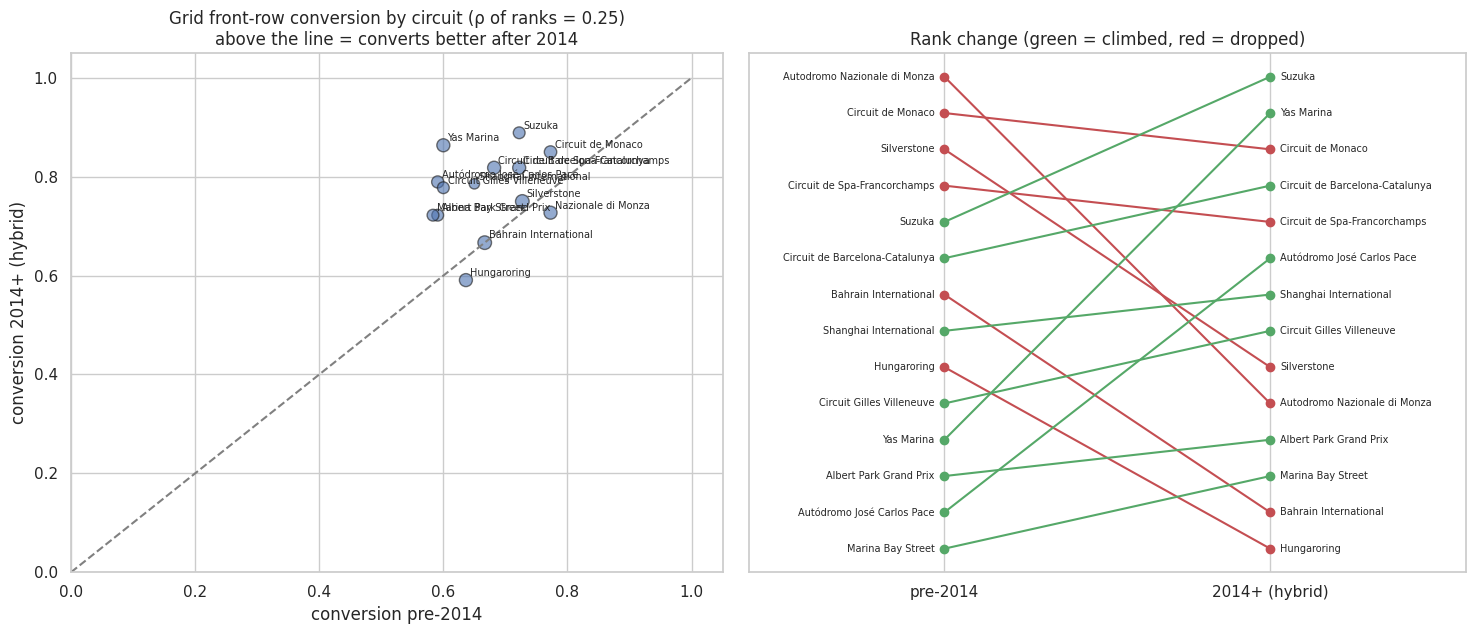

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1, 1.1]})

ax = axes[0]
x, y = cmp_grid[f"rate_{ERAS[0]}"], cmp_grid[f"rate_{ERAS[1]}"]
ax.scatter(x, y, s=cmp_grid[f"n_{ERAS[1]}"] * 4, alpha=.6, color="#4C72B0", edgecolor="k")
for name, xi, yi in zip(cmp_grid.index, x, y):
    ax.annotate(name.replace(" Circuit", "").replace("Autodromo ", ""), (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.plot([0, 1], [0, 1], ls="--", color="grey")
ax.set(xlim=(0, 1.05), ylim=(0, 1.05), xlabel=f"conversion {ERAS[0]}", ylabel=f"conversion {ERAS[1]}",
       title=f"Grid front-row conversion by circuit (ρ of ranks = {rho:.2f})\nabove the line = converts better after 2014")

ax = axes[1]
s = cmp_grid.sort_values("rank_pre")
for name, r0, r1 in zip(s.index, s.rank_pre, s.rank_post):
    col = "#55A868" if r1 < r0 else ("#C44E52" if r1 > r0 else "grey")
    ax.plot([0, 1], [r0, r1], color=col, marker="o")
    ax.text(-0.03, r0, name.replace(" Circuit", ""), ha="right", va="center", fontsize=7)
    ax.text(1.03, r1, name.replace(" Circuit", ""), ha="left", va="center", fontsize=7)
ax.invert_yaxis(); ax.set_xticks([0, 1]); ax.set_xticklabels(ERAS); ax.set_xlim(-0.6, 1.6)
ax.set_yticks([]); ax.set_title("Rank change (green = climbed, red = dropped)")
plt.tight_layout(); savefig("q1_rank_change"); plt.show()

In [33]:
# Auto-generated summary to copy into the report
g = conv["grid"]
for e in ERAS:
    top = g[g.era == e].head(5)
    print(f"{e}: top-5 by grid front-row conversion → " +
          "; ".join(f"{c} {r:.0%} ({k}/{n})" for c, r, k, n in zip(top.circuit_name, top.rate, top.podiums, top.n)))
qr = overall.set_index("definition")["rate"]
print(f"\nOverall conversion {QUALI_START}+: qualifying front row {qr.iloc[0]:.1%}, grid front row {qr.iloc[1]:.1%}.")
print(f"Ranking stability across 2014: Spearman ρ = {rho:.2f} over {len(cmp_grid)} circuits.")

pre-2014: top-5 by grid front-row conversion → Circuit de Nevers Magny-Cours 92% (11/12); Autodromo Nazionale di Monza 77% (17/22); Circuit de Monaco 77% (17/22); Istanbul Park 79% (11/14); Silverstone Circuit 73% (16/22)
2014+ (hybrid): top-5 by grid front-row conversion → Suzuka Circuit 89% (16/18); Yas Marina Circuit 86% (19/22); Circuit de Monaco 85% (17/20); Circuit de Barcelona-Catalunya 82% (18/22); Circuit de Spa-Francorchamps 82% (18/22)

Overall conversion 2003+: qualifying front row 70.7%, grid front row 72.2%.
Ranking stability across 2014: Spearman ρ = 0.25 over 14 circuits.


**Q1 answer** (Ergast data 1950–2024; numbers printed above)

**Window.** `qualifying` is complete only from **2003** (1994–2002 coverage drops to 6–59% per season, see `q1_qualifying_coverage.png`), so Q1 compares **2003–2013 ("pre-2014")** with **2014–2024 (hybrid)**. Both definitions use exactly the same races.

**Which circuits convert best?** (front row by grid, ≥10 front-row starts, ranked by Wilson lower bound)
- 2003–2013: Magny-Cours 92% (11/12), Monza 77% (17/22), Monaco 77% (17/22), Istanbul Park 79% (11/14), Silverstone 73% (16/22).
- 2014–2024: Suzuka 89% (16/18), Yas Marina 86% (19/22), Monaco 85% (17/20), Barcelona 82% (18/22), Spa 82% (18/22).

**Does the ranking change after 2014? Yes, substantially.** Among the 14 circuits with enough starts in both eras, the rank correlation is only ρ = 0.25 (p = 0.38). The biggest climbers are Yas Marina (11th → 2nd), Interlagos (13th → 6th) and Suzuka (5th → 1st). The biggest fallers are Monza (1st → 10th), Bahrain (7th → 13th) and Silverstone (3rd → 9th). Monaco stays near the top in both eras, which fits a track where overtaking is hardest. Most circuits sit above the diagonal in `q1_rank_change.png`, so conversion rose overall in the hybrid era. That is consistent with seasons dominated by one team, but this analysis does not test the cause.

**Qualifying vs grid.** The two usually agree: 818 of ~855 front-row cases qualified *and* started there, and the overall conversion is similar (qualifying 70.7%, grid 72.2%). The difference matters where they disagree. Drivers who **qualified on the front row but started further back** (penalties / pit-lane, n = 38) reached the podium only **29%** of the time, vs **73%** for those who kept their front-row slot. Drivers **promoted** onto the front row converted 64% (n = 36). So grid is the right definition of a "front-row start"; using qualifying would credit penalised drivers with a start they never had. The circuit rankings from both definitions are very similar (ρ = 0.94 pre-2014, 0.88 after), so the ranking conclusion holds under either definition.

**Grain / missingness / cutoff.** One front-row starter per race (≈2 rows per race). Seasons before 2003 are excluded because qualifying is missing. Qualifying position and grid are both fixed before the race; the podium is only the outcome. Samples per circuit are small (12–26 starts), so the confidence intervals overlap heavily and neighbouring ranks should not be over-read.

## 3. Q2 — Do drivers podium more often at home, after controlling for starting position?

**Home race** = the driver's nationality (`drivers.nationality`) maps to the country of the circuit (`races → circuits.country`). Nationality is a demonym ("British") and circuits store a country ("UK"), so we use an explicit mapping and **print anything that does not map** rather than dropping it silently.

**Why control for grid?** Grid is by far the strongest pre-race driver of podiums. If home drivers qualify better (motivation, track knowledge, or simply because strong nations host many races) a raw comparison would mix that in. We compare home vs away **within the same grid band** (stratification), then pool across bands with the Cochran–Mantel–Haenszel (CMH) odds ratio, and confirm with a logistic regression `podium ~ home + grid band + decade`.

**Grain:** one driver in one race. **Exclusions:** `grid = 0` (pit-lane start / starting slot unknown, so the control variable is missing) and the **Indianapolis 500** (1950–60): it counted for the championship but was entered almost only by American drivers who never raced elsewhere, so it is a different competition that would inflate "home" for the USA. A sensitivity check includes it again.

In [34]:
NATIONALITY_TO_COUNTRY = {
    "American": "USA", "American-Italian": "USA", "Argentine": "Argentina", "Argentinian": "Argentina",
    "Argentine-Italian": "Argentina", "Australian": "Australia", "Austrian": "Austria", "Belgian": "Belgium",
    "Brazilian": "Brazil", "British": "UK", "Canadian": "Canada", "Chilean": "Chile", "Chinese": "China",
    "Colombian": "Colombia", "Czech": "Czech Republic", "Danish": "Denmark", "Dutch": "Netherlands",
    "East German": "Germany", "Finnish": "Finland", "French": "France", "German": "Germany",
    "Hong Kong": "Hong Kong", "Hungarian": "Hungary", "Indian": "India", "Indonesian": "Indonesia",
    "Irish": "Ireland", "Italian": "Italy", "Japanese": "Japan", "Liechtensteiner": "Liechtenstein",
    "Malaysian": "Malaysia", "Mexican": "Mexico", "Monegasque": "Monaco", "Moroccan": "Morocco",
    "New Zealander": "New Zealand", "Polish": "Poland", "Portuguese": "Portugal", "Rhodesian": "Rhodesia",
    "Russian": "Russia", "South African": "South Africa", "Spanish": "Spain", "Swedish": "Sweden",
    "Swiss": "Switzerland", "Thai": "Thailand", "Uruguayan": "Uruguay", "Venezuelan": "Venezuela",
    "Saudi": "Saudi Arabia", "Emirati": "UAE", "Chinese Taipei": "Taiwan", "Estonian": "Estonia",
    "Israeli": "Israel",
}
unmapped = sorted(set(base.driver_nationality.dropna()) - set(NATIONALITY_TO_COUNTRY))
print("Nationalities without a mapping (treated as never-home):", unmapped or "none")
host_without_driver = sorted(set(base.circuit_country.dropna()) - set(NATIONALITY_TO_COUNTRY.values()))
print("Host countries with no driver of that nationality (no home races possible):", host_without_driver)

base["driver_country"] = base["driver_nationality"].map(NATIONALITY_TO_COUNTRY)
base["home"] = (base["driver_country"] == base["circuit_country"]).astype(int)
base["is_indy500"] = base["race_name"].str.contains("Indianapolis", case=False, na=False)

GRID_BINS = [0, 1, 2, 3, 5, 10, 15, np.inf]
GRID_LABELS = ["P1", "P2", "P3", "P4–5", "P6–10", "P11–15", "P16+"]

def q2_frame(df, include_indy=False, year_from=None):
    d = df[df["grid"] >= 1]
    if not include_indy: d = d[~d["is_indy500"]]
    if year_from: d = d[d["year"] >= year_from]
    d = d.copy()
    d["grid_band"] = pd.cut(d["grid"], GRID_BINS, labels=GRID_LABELS)
    d["decade"] = (d["year"] // 10 * 10).astype(int)
    return d

q2 = q2_frame(base)
print(f"\nQ2 sample: {len(q2):,} driver-race starts, {q2.home.sum():,} at home ({q2.home.mean():.1%}).")
print(f"Dropped: grid=0 rows {int((base.grid < 1).sum()):,}; Indy 500 rows {int((base.is_indy500 & (base.grid >= 1)).sum()):,}")

Nationalities without a mapping (treated as never-home): none
Host countries with no driver of that nationality (no home races possible): ['Azerbaijan', 'Bahrain', 'Korea', 'Qatar', 'Singapore', 'Turkey']

Q2 sample: 24,652 driver-race starts, 1,943 at home (7.9%).
Dropped: grid=0 rows 1,635; Indy 500 rows 381


### 3.1 Raw comparison, and why it is confounded

,starts,podiums,mean_grid,median_grid,podium_rate
home,,,,,
away,22709,3129,11.703686,11.0,0.137787
home,1943,230,12.700463,13.0,0.118374


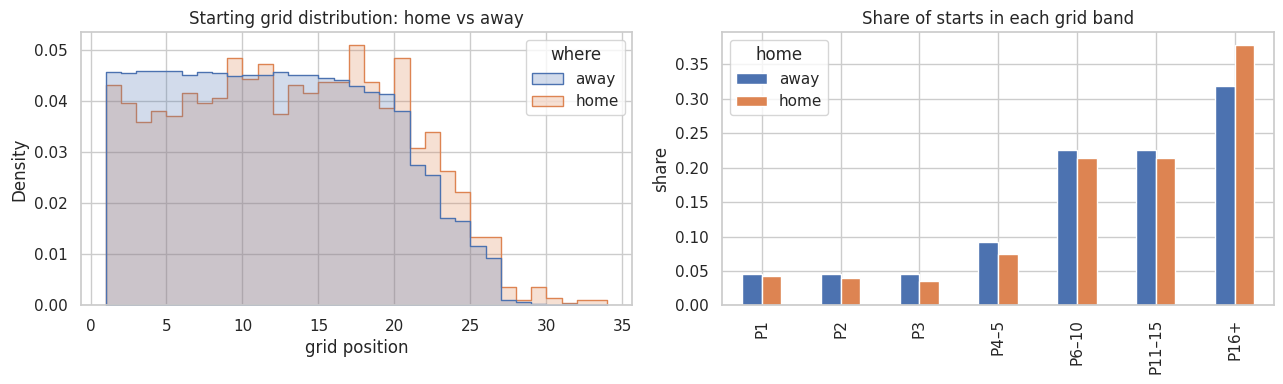

In [35]:
raw_cmp = q2.groupby("home").agg(starts=("podium", "size"), podiums=("podium", "sum"),
                                 mean_grid=("grid", "mean"), median_grid=("grid", "median"))
raw_cmp["podium_rate"] = raw_cmp.podiums / raw_cmp.starts
raw_cmp.index = raw_cmp.index.map({0: "away", 1: "home"})
display(raw_cmp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=q2.assign(where=q2.home.map({0: "away", 1: "home"})), x="grid", hue="where",
             stat="density", common_norm=False, binwidth=1, element="step", ax=axes[0])
axes[0].set(title="Starting grid distribution: home vs away", xlabel="grid position")
mix = pd.crosstab(q2.home, q2.grid_band, normalize="index")
mix.index = mix.index.map({0: "away", 1: "home"})
mix.T.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set(title="Share of starts in each grid band", ylabel="share", xlabel="")
plt.tight_layout(); savefig("q2_grid_mix"); plt.show()

### 3.2 Stratified by grid band

n        podiums            rate          
where        away   home    away  home      away      home
grid_band                                                 
P1         1040.0   84.0   673.0  52.0  0.647115  0.619048
P2         1034.0   77.0   581.0  44.0  0.561896  0.571429
P3         1044.0   70.0   479.0  37.0  0.458812  0.528571
P4–5       2088.0  146.0   616.0  51.0  0.295019  0.349315
P6–10      5143.0  417.0   576.0  34.0  0.111997  0.081535
P11–15     5124.0  415.0   151.0  10.0  0.029469  0.024096
P16+       7236.0  734.0    53.0   2.0  0.007324  0.002725

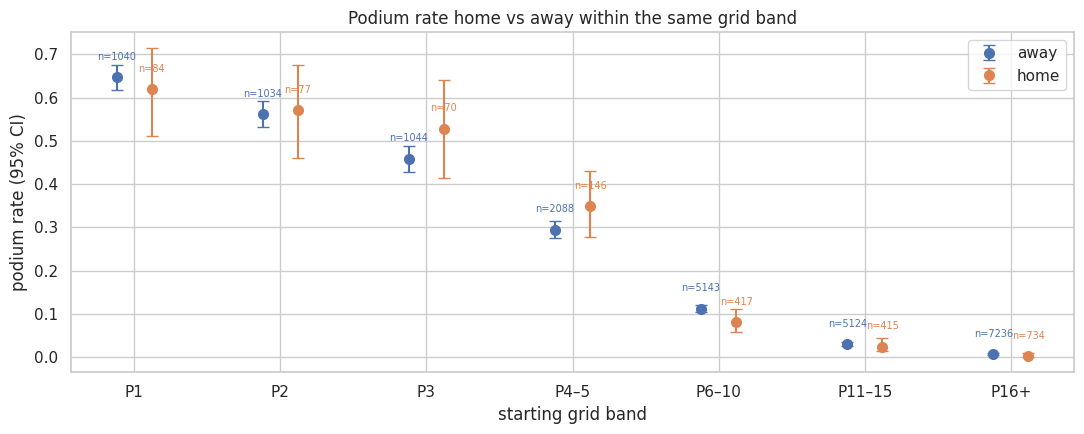

In [36]:
strat = (q2.groupby(["grid_band", "home"], observed=True)
           .agg(n=("podium", "size"), podiums=("podium", "sum")).reset_index())
strat["rate"] = strat.podiums / strat.n
strat["ci_lo"], strat["ci_hi"] = wilson(strat.podiums, strat.n)
strat["where"] = strat.home.map({0: "away", 1: "home"})
display(strat.pivot(index="grid_band", columns="where", values=["n", "podiums", "rate"]))

fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(len(GRID_LABELS))
for k, (w, col, off) in enumerate([("away", "#4C72B0", -0.12), ("home", "#DD8452", 0.12)]):
    s = strat[strat["where"] == w].set_index("grid_band").reindex(GRID_LABELS)
    ax.errorbar(xs + off, s.rate, yerr=[s.rate - s.ci_lo, s.ci_hi - s.rate], fmt="o", color=col,
                capsize=4, label=w, ms=7)
    for x, r, n in zip(xs + off, s.rate, s.n):
        if pd.notna(n): ax.text(x, (r or 0) + 0.04, f"n={int(n)}", ha="center", fontsize=7, color=col)
ax.set_xticks(xs); ax.set_xticklabels(GRID_LABELS)
ax.set(ylabel="podium rate (95% CI)", xlabel="starting grid band",
       title="Podium rate home vs away within the same grid band")
ax.legend(); plt.tight_layout(); savefig("q2_stratified"); plt.show()

### 3.3 Pooled effect: Cochran–Mantel–Haenszel and logistic regression
- **CMH odds ratio**: one combined home-vs-away odds ratio across grid bands, each band compared only with itself. OR > 1 ⇒ home drivers podium more often than away drivers who started from a similar slot. Breslow–Day tests whether the effect differs across bands.
- **Logistic regression** adds decade fixed effects (podium base rates changed as grids grew from ~20 to 20+ cars and reliability improved).

In [37]:
def cmh(d):
    tables = []
    for _, g in d.groupby("grid_band", observed=True):
        t = np.array([[((g.home == 1) & (g.podium == 1)).sum(), ((g.home == 1) & (g.podium == 0)).sum()],
                      [((g.home == 0) & (g.podium == 1)).sum(), ((g.home == 0) & (g.podium == 0)).sum()]])
        if (t.sum(axis=1) > 0).all() and t[:, 0].sum() > 0 and t[:, 1].sum() > 0:
            tables.append(t)
    st = StratifiedTable(tables)
    lo, hi = st.oddsratio_pooled_confint()
    return {"OR_CMH": st.oddsratio_pooled, "CI_lo": lo, "CI_hi": hi,
            "p_CMH": st.test_null_odds().pvalue, "p_homogeneity": st.test_equal_odds().pvalue,
            "home_starts": int(d.home.sum()), "strata": len(tables)}

cmh_main = cmh(q2)
display(pd.Series(cmh_main).to_frame("value").T.style.format(precision=3))

logit = smf.logit("podium ~ home + C(grid_band) + C(decade)", data=q2).fit(disp=0)
or_home = np.exp(logit.params["home"]); ci = np.exp(logit.conf_int().loc["home"])
print(f"Logistic regression: OR(home) = {or_home:.2f}  95% CI [{ci[0]:.2f}, {ci[1]:.2f}],  p = {logit.pvalues['home']:.3g}")

,OR_CMH,CI_lo,CI_hi,p_CMH,p_homogeneity,home_starts,strata
value,0.952,0.800,1.132,0.580,0.145,1943.000,7.000


Logistic regression: OR(home) = 0.94  95% CI [0.79, 1.12],  p = 0.511


### 3.4 Sensitivity: does the conclusion depend on choices we made?

,OR_CMH,CI_lo,CI_hi,p_CMH,p_homogeneity,home_starts,strata
"Main (all years, excl. Indy 500)",0.95,0.80,1.13,0.58,0.145,1943.000000,7.000000
Including Indy 500,0.95,0.81,1.11,0.534,0.577,2323.000000,7.000000
1980 onward,0.92,0.72,1.16,0.46,0.313,1045.000000,7.000000
2000 onward,0.71,0.49,1.03,0.0737,0.559,434.000000,7.000000
2014 onward,0.83,0.45,1.55,0.558,0.658,144.000000,7.000000


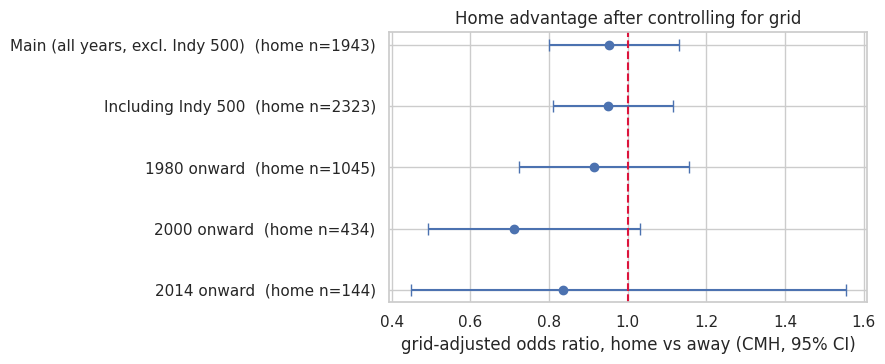

In [38]:
variants = {
    "Main (all years, excl. Indy 500)": q2_frame(base),
    "Including Indy 500": q2_frame(base, include_indy=True),
    "1980 onward": q2_frame(base, year_from=1980),
    "2000 onward": q2_frame(base, year_from=2000),
    f"{HYBRID_START} onward": q2_frame(base, year_from=HYBRID_START),
}
sens = pd.DataFrame({k: cmh(v) for k, v in variants.items()}).T
display(sens.style.format({"OR_CMH": "{:.2f}", "CI_lo": "{:.2f}", "CI_hi": "{:.2f}",
                           "p_CMH": "{:.3g}", "p_homogeneity": "{:.3g}"}))

fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(sens))[::-1]
ax.errorbar(sens.OR_CMH, y, xerr=[sens.OR_CMH - sens.CI_lo, sens.CI_hi - sens.OR_CMH], fmt="o",
            color="#4C72B0", capsize=4)
ax.axvline(1, color="crimson", ls="--")
ax.set_yticks(y); ax.set_yticklabels([f"{k}  (home n={int(v)})" for k, v in zip(sens.index, sens.home_starts)])
ax.set(xlabel="grid-adjusted odds ratio, home vs away (CMH, 95% CI)", title="Home advantage after controlling for grid")
plt.tight_layout(); savefig("q2_forest"); plt.show()

In [39]:
s = cmh_main
verdict = ("higher" if s["CI_lo"] > 1 else "lower" if s["CI_hi"] < 1 else "not distinguishable from")
print(f"Raw podium rate: home {raw_cmp.loc['home','podium_rate']:.1%} vs away {raw_cmp.loc['away','podium_rate']:.1%}.")
print(f"Grid-adjusted (CMH) OR = {s['OR_CMH']:.2f} [{s['CI_lo']:.2f}, {s['CI_hi']:.2f}], p = {s['p_CMH']:.3g} "
      f"→ home podium odds are {verdict} away odds for drivers starting from similar positions.")
print(f"Effect homogeneous across grid bands? Breslow–Day p = {s['p_homogeneity']:.3g}")

Raw podium rate: home 11.8% vs away 13.8%.
Grid-adjusted (CMH) OR = 0.95 [0.80, 1.13], p = 0.58 → home podium odds are not distinguishable from away odds for drivers starting from similar positions.
Effect homogeneous across grid bands? Breslow–Day p = 0.145


**Q2 answer**

**Raw comparison.** Home drivers podium *less* often: 11.8% (230/1,943) vs 13.8% (3,129/22,709) away. They also start further back on average (grid 12.7 vs 11.7), partly because many home entries in early decades were local one-off drivers. This is exactly why the raw comparison cannot answer the question.

**After controlling for starting position: no home advantage.**
- Within grid bands the home and away rates are close, and the direction flips. Home drivers do slightly better from P3 (53% vs 46%) and P4–5 (35% vs 30%), but worse from P1 (62% vs 65%) and P6–10 (8% vs 11%). Every home CI overlaps the away CI (`q2_stratified.png`).
- Pooled CMH odds ratio = **0.95 (95% CI 0.80–1.13), p = 0.58**. Logistic regression with grid band + decade gives OR = 0.94 (0.79–1.12), p = 0.51. The Breslow–Day test (p = 0.15) finds no evidence that the effect differs between grid bands.
- Sensitivity (`q2_forest.png`): the CI includes 1 in every variant, whether the Indy 500 is included, or the sample is restricted to 1980+, 2000+ or 2014+. The 2000+ estimate leans *below* 1 (0.71, 0.49–1.03), and the 2014+ sample is too small to conclude anything (144 home starts).

**Conclusion.** Once drivers who start from similar grid positions are compared, racing at home is **not associated with a higher podium rate** in this data. This is an association, not a causal estimate. Nationality is used as a proxy for "home", dual nationalities are mapped to one country, and home starts are only ~8% of the sample.

**Grain / missingness / cutoff.** One driver per race. 1,635 `grid = 0` rows were excluded because the control variable is missing, and 381 Indy 500 rows were excluded (re-included as a sensitivity check). Only the pre-race grid is used as the control.

## 4. Q3 — Mechanical-retirement rate by constructor, 2014–2021 vs 2022–2024

**Definition (from the brief):** a mechanical retirement is a race **start** that ended early because a **car component failed** — not a crash, not the driver, not a regulation decision.

- **Numerator:** starts whose `status` is a component failure (engine, gearbox, hydraulics, power unit, ERS, brakes, …).
- **Denominator:** race starts = entries **excluding** "Did not start / Withdrew / Did not qualify / 107% Rule" (no start → cannot retire).
- **Ambiguous statuses** such as "Retired", "Damage", "Debris", "Puncture", "Wheel nut", "Out of fuel" could be a failure *or* a crash/pit-stop/strategy issue. They are **not** counted in the main rate, but a sensitivity "upper bound" counts them, so the reader can see whether the ranking depends on that choice.

**Grain:** one constructor-car start in one race (sprint races are not in `results.csv`). Status is post-race information — it is used here only as the *answer* to a descriptive question, never as a model feature.

In [40]:
NOT_STARTED = {"Did not qualify", "Did not prequalify", "Withdrew", "Did not start", "107% Rule", "Not qualified"}
NON_MECHANICAL = {  # crash / driver / regulation
    "Accident", "Collision", "Collision damage", "Spun off", "Disqualified", "Excluded", "Underweight",
    "Illness", "Driver unwell", "Physical", "Injured", "Injury", "Eye injury", "Fatal accident",
    "Safety", "Safety concerns",
}
AMBIGUOUS = {
    "Retired", "Not classified", "Puncture", "Tyre", "Tyre puncture", "Wheel", "Wheel nut", "Loose wheel",
    "Damage", "Debris", "Front wing", "Rear wing", "Broken wing", "Out of fuel", "Refuelling", "Fuel rig",
    "Handling", "Stalled", "Not restarted",
}
MECHANICAL = {
    "Engine", "Gearbox", "Transmission", "Clutch", "Hydraulics", "Electrical", "Radiator", "Suspension", "Brakes",
    "Differential", "Overheating", "Mechanical", "Driveshaft", "Fuel pressure", "Water pressure", "Throttle",
    "Steering", "Technical", "Electronics", "Heat shield fire", "Exhaust", "Oil leak", "Wheel rim", "Water leak",
    "Fuel pump", "Track rod", "Oil pressure", "Engine fire", "Engine misfire", "Pneumatics", "Fire", "Wheel bearing",
    "Fuel system", "Oil line", "Launch control", "Fuel", "Power loss", "Drivetrain", "Ignition", "Chassis", "Battery",
    "Halfshaft", "Crankshaft", "Alternator", "Oil pump", "Fuel leak", "Injection", "Distributor", "Turbo", "CV joint",
    "Water pump", "Spark plugs", "Fuel pipe", "Oil pipe", "Axle", "Water pipe", "Magneto", "Supercharger",
    "Power Unit", "ERS", "Brake duct", "Cooling system", "Undertray", "Driver Seat", "Seat", "Safety belt",
    "Vibrations", "Fuel injection", "Engine overheating",
}
MECH_KEYWORDS = r"engine|gear|hydraul|electr|brake|suspens|oil|water|fuel|turbo|power|clutch|transmission|cool"

def classify_status(s):
    if pd.isna(s): return "unclassified"
    if s == "Finished" or re.fullmatch(r"\+\d+ Laps?", s): return "finished"
    if s in NOT_STARTED: return "did not start"
    if s in MECHANICAL: return "mechanical"
    if s in NON_MECHANICAL: return "crash / driver / regulation"
    if s in AMBIGUOUS: return "ambiguous"
    if re.search(MECH_KEYWORDS, s, re.I): return "mechanical"
    return "unclassified"

status_map = tbl["status"].assign(category=tbl["status"]["status"].map(classify_status))
base = base.drop(columns="category", errors="ignore").merge(status_map[["statusId", "category"]], on="statusId", how="left")

q3 = base[(base.year >= 2014) & (base.year <= 2024)].copy()
q3["period"] = np.where(q3.year <= 2021, "2014–2021", "2022–2024")

# Audit: every status that occurs in the window and how it was classified
audit = (q3.groupby(["category", "status"]).size().rename("rows").reset_index()
           .sort_values(["category", "rows"], ascending=[True, False]))
print("Unclassified statuses in 2014–2024:", audit.loc[audit.category == "unclassified", "status"].tolist() or "none")
audit

Unclassified statuses in 2014–2024: none


,category,status,rows
6,ambiguous,Retired,50
8,ambiguous,Wheel,11
4,ambiguous,Puncture,7
7,ambiguous,Tyre,4
2,ambiguous,Front wing,3
5,ambiguous,Rear wing,3
9,ambiguous,Wheel nut,3
0,ambiguous,Damage,2
1,ambiguous,Debris,1
3,ambiguous,Out of fuel,1


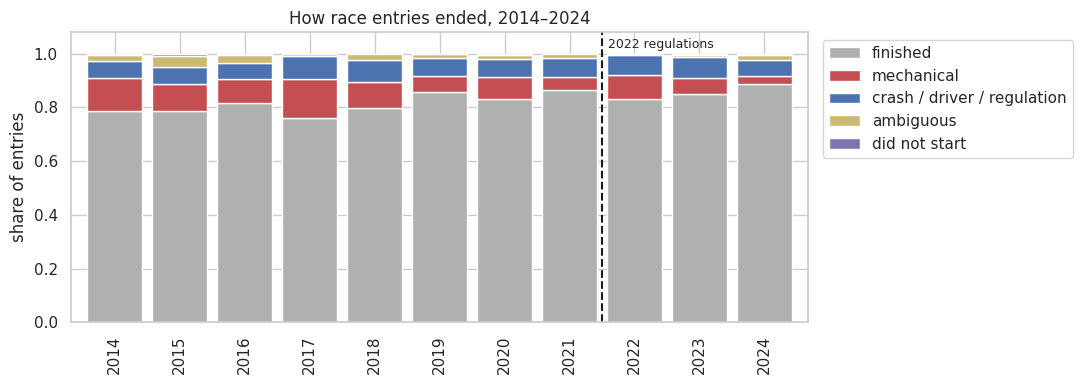

In [41]:
# Context: what share of entries ended each way, per season?
comp = pd.crosstab(q3.year, q3.category, normalize="index")
order = [c for c in ["finished", "mechanical", "crash / driver / regulation", "ambiguous", "did not start", "unclassified"] if c in comp]
colors = {"finished": "#B0B0B0", "mechanical": "#C44E52", "crash / driver / regulation": "#4C72B0",
          "ambiguous": "#CCB974", "did not start": "#8172B2", "unclassified": "#000000"}
fig, ax = plt.subplots(figsize=(11, 4))
comp[order].plot(kind="bar", stacked=True, ax=ax, color=[colors[c] for c in order], width=.85)
ax.axvline(7.5, color="k", ls="--"); ax.text(7.6, 1.02, "2022 regulations", fontsize=9)
ax.set(ylabel="share of entries", xlabel="", title="How race entries ended, 2014–2024")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); ax.set_ylim(0, 1.08)
plt.tight_layout(); savefig("q3_status_composition"); plt.show()

In [42]:
MIN_STARTS = 20   # starts per constructor per period (≈ half a season with two cars)

starts = q3[q3.category != "did not start"]
rate = (starts.groupby(["period", "constructor"])
          .agg(starts=("category", "size"),
               mech=("category", lambda c: (c == "mechanical").sum()),
               ambig=("category", lambda c: (c == "ambiguous").sum()),
               seasons=("year", "nunique"))
          .reset_index())
rate["mech_rate"] = rate.mech / rate.starts
rate["ci_lo"], rate["ci_hi"] = wilson(rate.mech, rate.starts)
rate["upper_bound_rate"] = (rate.mech + rate.ambig) / rate.starts
rate = rate[rate.starts >= MIN_STARTS].sort_values(["period", "mech_rate"], ascending=[True, False])

for p_ in ["2014–2021", "2022–2024"]:
    print(f"\n{p_}")
    display(rate[rate.period == p_][["constructor", "seasons", "starts", "mech", "mech_rate", "ci_lo", "ci_hi", "upper_bound_rate"]]
            .style.format({"mech_rate": "{:.1%}", "ci_lo": "{:.1%}", "ci_hi": "{:.1%}", "upper_bound_rate": "{:.1%}"})
            .hide(axis="index"))


2014–2021


constructor,seasons,starts,mech,mech_rate,ci_lo,ci_hi,upper_bound_rate
Caterham,1,34,8,23.5%,12.4%,40.0%,32.4%
Lotus F1,2,75,13,17.3%,10.4%,27.4%,24.0%
Toro Rosso,6,242,39,16.1%,12.0%,21.3%,18.2%
McLaren,8,318,44,13.8%,10.5%,18.1%,16.0%
Renault,5,200,27,13.5%,9.4%,18.9%,16.5%
Sauber,5,200,22,11.0%,7.4%,16.1%,13.5%
Red Bull,8,319,34,10.7%,7.7%,14.5%,11.9%
AlphaTauri,2,78,8,10.3%,5.3%,19.0%,11.5%
Marussia,1,31,3,9.7%,3.3%,24.9%,9.7%
Racing Point,2,76,7,9.2%,4.5%,17.8%,10.5%



2022–2024


constructor,seasons,starts,mech,mech_rate,ci_lo,ci_hi,upper_bound_rate
Alfa Romeo,2,88,11,12.5%,7.1%,21.0%,12.5%
Alpine F1 Team,3,136,15,11.0%,6.8%,17.4%,11.0%
AlphaTauri,2,88,7,8.0%,3.9%,15.5%,8.0%
Ferrari,3,136,9,6.6%,3.5%,12.1%,8.1%
Williams,3,134,8,6.0%,3.1%,11.3%,8.2%
Aston Martin,3,133,6,4.5%,2.1%,9.5%,6.0%
Haas F1 Team,3,135,6,4.4%,2.1%,9.4%,5.2%
Mercedes,3,136,6,4.4%,2.0%,9.3%,4.4%
RB F1 Team,1,48,2,4.2%,1.2%,14.0%,10.4%
McLaren,3,136,5,3.7%,1.6%,8.3%,3.7%


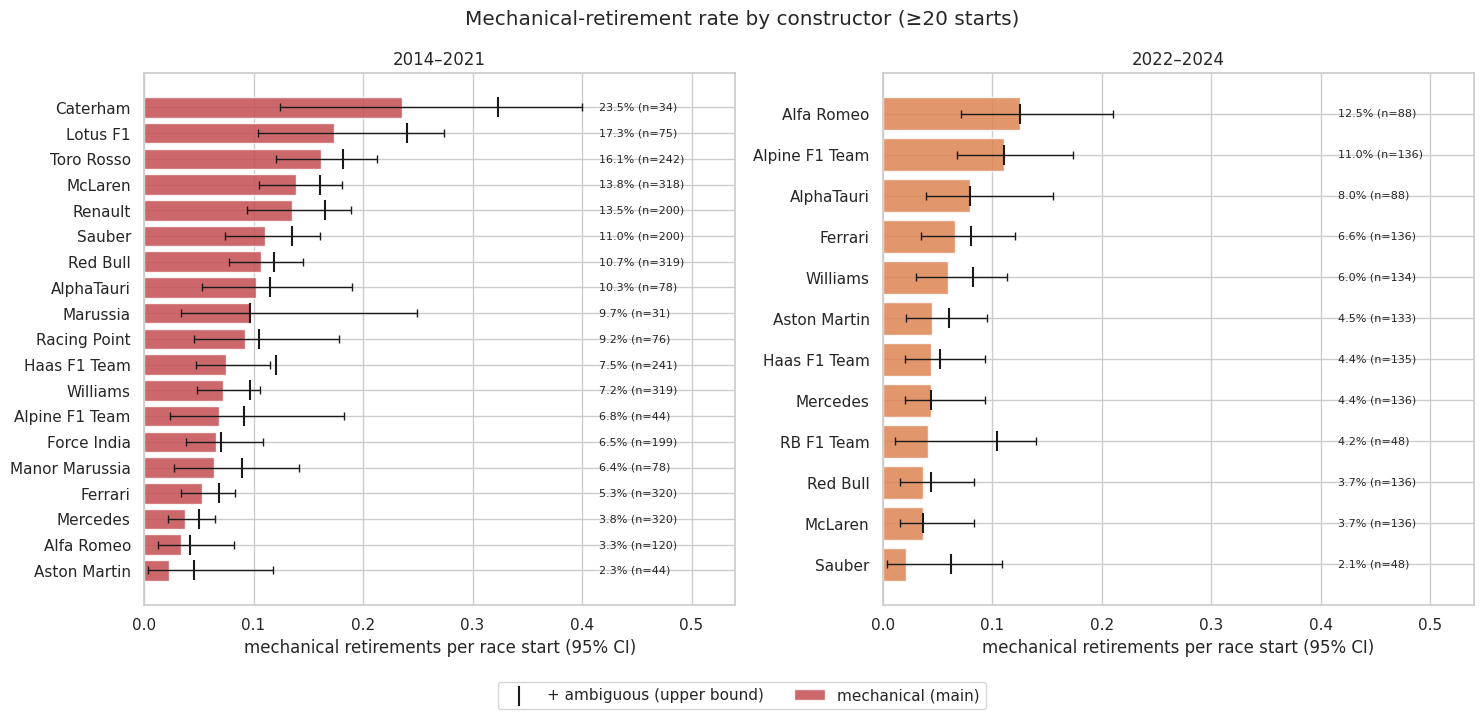

In [43]:
XMAX = max(rate.ci_hi.max(), rate.upper_bound_rate.max())
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
for ax, p_, col in zip(axes, ["2014–2021", "2022–2024"], ["#C44E52", "#DD8452"]):
    t = rate[rate.period == p_].sort_values("mech_rate")
    ax.barh(t.constructor, t.mech_rate, color=col, alpha=.85, label="mechanical (main)")
    ax.errorbar(t.mech_rate, t.constructor, xerr=[t.mech_rate - t.ci_lo, t.ci_hi - t.mech_rate],
                fmt="none", ecolor="k", capsize=3, lw=1)
    ax.scatter(t.upper_bound_rate, t.constructor, marker="|", s=200, color="k", label="+ ambiguous (upper bound)")
    for y, (r, n) in enumerate(zip(t.mech_rate, t.starts)):
        ax.text(XMAX * 1.04, y, f"{r:.1%} (n={n})", va="center", fontsize=8)
    ax.set(title=f"{p_}", xlabel="mechanical retirements per race start (95% CI)", xlim=(0, XMAX * 1.35))
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03))
fig.suptitle(f"Mechanical-retirement rate by constructor (≥{MIN_STARTS} starts)")
plt.tight_layout(rect=(0, 0.03, 1, 1)); savefig("q3_mech_rate_by_constructor"); plt.show()

### 4.1 Same constructor, both periods
Several teams were **renamed** (Toro Rosso → AlphaTauri → RB, Force India → Racing Point → Aston Martin, Lotus F1 → Renault → Alpine, Sauber ↔ Alfa Romeo). Ergast gives each name its own `constructorId`, so the tables above follow the official entrant names. Below we also group by **team lineage** (same factory) — as an extra view, not a replacement — so a team's change across 2022 can be compared.

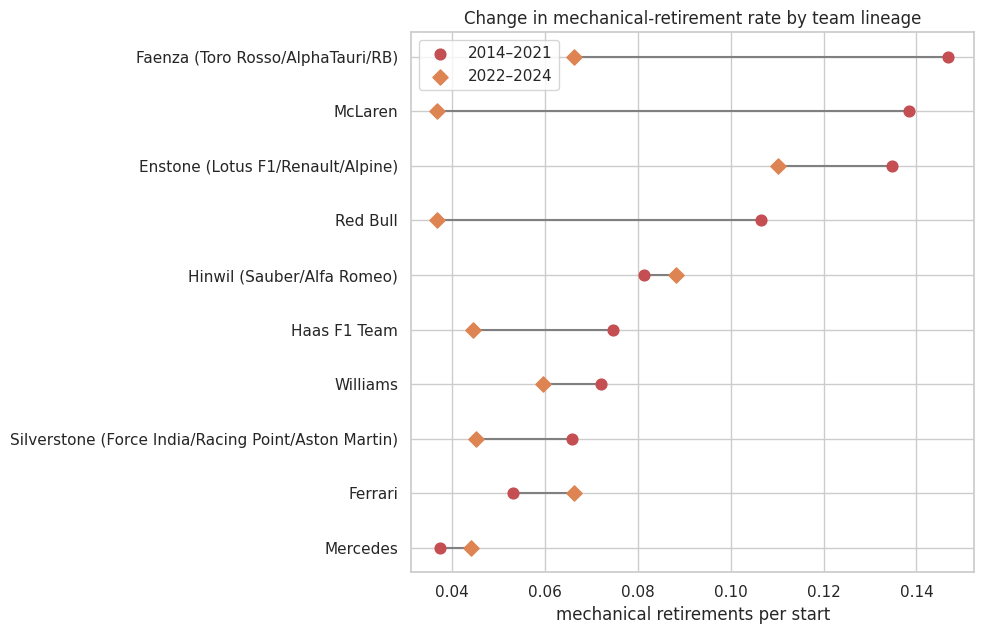

period,2014–2021,2022–2024,change_pp
team,,,
Mercedes,3.8%,4.4%,+0.7 pp
Ferrari,5.3%,6.6%,+1.3 pp
Silverstone (Force India/Racing Point/Aston Martin),6.6%,4.5%,-2.1 pp
Williams,7.2%,6.0%,-1.2 pp
Haas F1 Team,7.5%,4.4%,-3.0 pp
Hinwil (Sauber/Alfa Romeo),8.1%,8.8%,+0.7 pp
Red Bull,10.7%,3.7%,-7.0 pp
Enstone (Lotus F1/Renault/Alpine),13.5%,11.0%,-2.5 pp
McLaren,13.8%,3.7%,-10.2 pp


In [44]:
LINEAGE = {"toro_rosso": "Faenza (Toro Rosso/AlphaTauri/RB)", "alphatauri": "Faenza (Toro Rosso/AlphaTauri/RB)",
           "rb": "Faenza (Toro Rosso/AlphaTauri/RB)",
           "force_india": "Silverstone (Force India/Racing Point/Aston Martin)",
           "racing_point": "Silverstone (Force India/Racing Point/Aston Martin)",
           "aston_martin": "Silverstone (Force India/Racing Point/Aston Martin)",
           "lotus_f1": "Enstone (Lotus F1/Renault/Alpine)", "renault": "Enstone (Lotus F1/Renault/Alpine)",
           "alpine": "Enstone (Lotus F1/Renault/Alpine)",
           "sauber": "Hinwil (Sauber/Alfa Romeo)", "alfa": "Hinwil (Sauber/Alfa Romeo)"}
starts = starts.assign(team=starts.constructorRef.map(LINEAGE).fillna(starts.constructor))
lin = (starts.groupby(["team", "period"])
             .agg(starts=("category", "size"), mech=("category", lambda c: (c == "mechanical").sum()))
             .reset_index())
lin["rate"] = lin.mech / lin.starts
lin["ci_lo"], lin["ci_hi"] = wilson(lin.mech, lin.starts)
w = lin[lin.starts >= MIN_STARTS].pivot(index="team", columns="period", values="rate").dropna()
w["change_pp"] = (w["2022–2024"] - w["2014–2021"]) * 100
w = w.sort_values("2014–2021")

fig, ax = plt.subplots(figsize=(10, 0.5 * len(w) + 1.5))
for y, (team, r) in enumerate(w.iterrows()):
    ax.plot([r["2014–2021"], r["2022–2024"]], [y, y], color="grey", zorder=1)
ax.scatter(w["2014–2021"], range(len(w)), color="#C44E52", label="2014–2021", zorder=2, s=60)
ax.scatter(w["2022–2024"], range(len(w)), color="#DD8452", label="2022–2024", zorder=2, s=60, marker="D")
ax.set_yticks(range(len(w))); ax.set_yticklabels(w.index)
ax.set(xlabel="mechanical retirements per start", title="Change in mechanical-retirement rate by team lineage")
ax.legend(); plt.tight_layout(); savefig("q3_lineage_dumbbell"); plt.show()
display(w.style.format({"2014–2021": "{:.1%}", "2022–2024": "{:.1%}", "change_pp": "{:+.1f} pp"}))

In [45]:
# Overall shift between periods (chi-square on mechanical vs not, among starts)
ct = pd.crosstab(starts.period, starts.category == "mechanical")
chi2, p_chi, _, _ = stats.chi2_contingency(ct)
overall_rate = starts.groupby("period")["category"].apply(lambda c: (c == "mechanical").mean())
print("Overall mechanical-retirement rate per start:", overall_rate.map("{:.1%}".format).to_dict(),
      f"| chi-square p = {p_chi:.3g}")

# Robustness of the ranking to the ambiguous-status choice
for p_ in ["2014–2021", "2022–2024"]:
    t = rate[rate.period == p_]
    r_, _ = stats.spearmanr(t.mech_rate, t.upper_bound_rate)
    top = t.head(3)
    print(f"{p_}: highest → " + "; ".join(f"{c} {r:.1%} ({m}/{n})" for c, r, m, n in
                                         zip(top.constructor, top.mech_rate, top.mech, top.starts))
          + f" | rank agreement strict vs upper-bound ρ = {r_:.2f}")

Overall mechanical-retirement rate per start: {'2014–2021': '9.2%', '2022–2024': '6.0%'} | chi-square p = 0.000324
2014–2021: highest → Caterham 23.5% (8/34); Lotus F1 17.3% (13/75); Toro Rosso 16.1% (39/242) | rank agreement strict vs upper-bound ρ = 0.97
2022–2024: highest → Alfa Romeo 12.5% (11/88); Alpine F1 Team 11.0% (15/136); AlphaTauri 8.0% (7/88) | rank agreement strict vs upper-bound ρ = 0.69


**Q3 answer**

**Highest mechanical-retirement rate per race start** (strict definition; ≥20 starts):
- **2014–2021:** Caterham 23.5% (8/34, one season only, so the CI is wide: 12–40%), Lotus F1 17.3% (13/75), Toro Rosso 16.1% (39/242), McLaren 13.8% (44/318), Renault 13.5% (27/200). The lowest were Mercedes 3.8% and Ferrari 5.3%.
- **2022–2024:** Alfa Romeo 12.5% (11/88), Alpine 11.0% (15/136), AlphaTauri 8.0% (7/88), Ferrari 6.6%, Williams 6.0%. The lowest were McLaren and Red Bull, both 3.7%.

**Change between periods.** Mechanical retirements fell from **9.2% to 6.0%** of starts (χ² p = 0.0003). Grouped by team lineage (`q3_lineage_dumbbell.png`), the biggest improvements were McLaren (−10.2 percentage points), the Faenza team (Toro Rosso → AlphaTauri/RB, −8.1 pp) and Red Bull (−7.0 pp). The 2014–2021 leaders are mostly teams that struggled with early hybrid power-unit reliability, which is consistent with this pattern. Ferrari (+1.3 pp), Mercedes (+0.7 pp) and Sauber/Alfa Romeo (+0.7 pp) changed little or got slightly worse.

**Robustness.** Counting the ambiguous statuses ("Retired", "Wheel", "Puncture"…) as mechanical barely changes the 2014–2021 ranking (ρ = 0.97). The 2022–2024 ranking is less stable (ρ = 0.69) because most teams sit within a few percentage points of each other there. Only the top two (Alfa Romeo, Alpine) are clearly separated.

**Caveats.** The `status` field gives only the official reason; "Retired" (50 cases in 2014–2024) hides the cause. Renamed teams are separate constructors unless the lineage view is used. 2022–2024 covers only 3 seasons, so its CIs are wider.

## 5. Summary

| Question | Main evidence | Figure(s) |
|---|---|---|
| Q1 | Front-row → podium conversion per circuit, ranked by Wilson lower bound; Spearman ρ across 2014; qualifying vs grid comparison | `q1_quali_vs_grid`, `q1_top_circuits`, `q1_rank_change` |
| Q2 | Stratified podium rates by grid band; CMH OR + logistic OR; sensitivity forest plot | `q2_grid_mix`, `q2_stratified`, `q2_forest` |
| Q3 | Mechanical starts / race starts with explicit status mapping; strict vs upper bound; lineage view | `q3_status_composition`, `q3_mech_rate_by_constructor`, `q3_lineage_dumbbell` |

All figures are saved in `figures_data_engineering/` for the report.

In [46]:
sorted(os.listdir(FIG_DIR))

['00_duplicate_pairs.png',
 'q1_quali_vs_grid.png',
 'q1_qualifying_coverage.png',
 'q1_rank_change.png',
 'q1_top_circuits.png',
 'q2_forest.png',
 'q2_grid_mix.png',
 'q2_stratified.png',
 'q3_lineage_dumbbell.png',
 'q3_mech_rate_by_constructor.png',
 'q3_status_composition.png']